In [53]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../best_data.csv")

In [4]:
months = ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6','Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']
features = ['Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST', 'SSTA', 'Percent_Bleaching']

In [5]:
df = df[features + months]

In [8]:
df['Status'] = np.where(df['Percent_Bleaching'] <= 1, True, False)
X = df.drop(columns=["Percent_Bleaching", "Status"])   # ⭐ ลบทั้งคู่
Y = df["Status"]

# PCA

In [20]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Class distribution:")
print(Y.value_counts())
print(Y.value_counts(normalize=True).round(3))
print(y_test[y_test == True].count()/y_test.count()*100)
print(y_train[y_train == True].count()/y_train.count()*100)

Class distribution:
Status
True     12088
False     9840
Name: count, dtype: int64
Status
True     0.551
False    0.449
Name: proportion, dtype: float64
55.608755129958965
55.005130543837645


In [21]:
X_train_raw_month, X_test_raw_month = X_train_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy(), X_test_raw[['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12']].copy()

X_train_raw_fe, X_test_fe = X_train_raw[['Depth_m', 'ClimSST', 'SSTA']].copy(), \
       X_test_raw[['Depth_m', 'ClimSST', 'SSTA']].copy()

X_train_raw_coor, X_test_coor = X_train_raw[['Latitude_Degrees', 'Longitude_Degrees']].copy(), \
       X_test_raw[['Latitude_Degrees', 'Longitude_Degrees']].copy()


X_train_raw = X_train_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Latitude_Degrees', 'Longitude_Degrees'])
X_test_raw = X_test_raw.drop(columns= ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6',
       'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Latitude_Degrees', 'Longitude_Degrees'])

In [46]:
# 1. Imputer สำหรับข้อมูลดิบหลัก
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp = imputer.transform(X_test_raw)

# 2. SEPARATE imputer for FE — and keep as DataFrame
fe_imputer = SimpleImputer(strategy='median')
X_train_raw_fe = pd.DataFrame(
    fe_imputer.fit_transform(X_train_raw_fe),
    columns=X_train_raw_fe.columns,
    index=X_train_raw_fe.index
)
X_test_fe = pd.DataFrame(
    fe_imputer.transform(X_test_fe),
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

# 3. SEPARATE imputer for COOR — and keep as DataFrame
coor_imputer = SimpleImputer(strategy='median')
X_train_raw_coor = pd.DataFrame(
    coor_imputer.fit_transform(X_train_raw_coor),
    columns=X_train_raw_coor.columns,  
    index=X_train_raw_coor.index      
)
X_test_coor = pd.DataFrame(
    coor_imputer.transform(X_test_coor),
    columns=X_test_coor.columns,     
    index=X_test_coor.index            
)

# 4. Scaler ตัวที่ 1 สำหรับข้อมูลหลัก
scaler = StandardScaler()
X_train_ss = scaler.fit_transform(X_train_imp)
X_test_ss = scaler.transform(X_test_imp)

# 5. Scaler ตัวที่ 2 แยกต่างหากสำหรับ COOR
coor_scaler = StandardScaler() 
X_train_ss_coor = coor_scaler.fit_transform(X_train_raw_coor)
X_test_ss_coor = coor_scaler.transform(X_test_coor)

# 6. PCA สำหรับฟีเจอร์หลัก (Environment)
pca_fe = PCA(n_components=1)
X_train_pca = pca_fe.fit_transform(X_train_ss)
X_test_pca = pca_fe.transform(X_test_ss)

# 7. PCA สำหรับพิกัด (Coordinates)
pca_coor = PCA(n_components=1)
X_train_coor_pca = pca_coor.fit_transform(X_train_ss_coor)
X_test_coor_pca = pca_coor.transform(X_test_ss_coor) # แก้ไขจาก fit_transform เป็น transform เพื่อป้องกันข้อมูลรั่วไหล

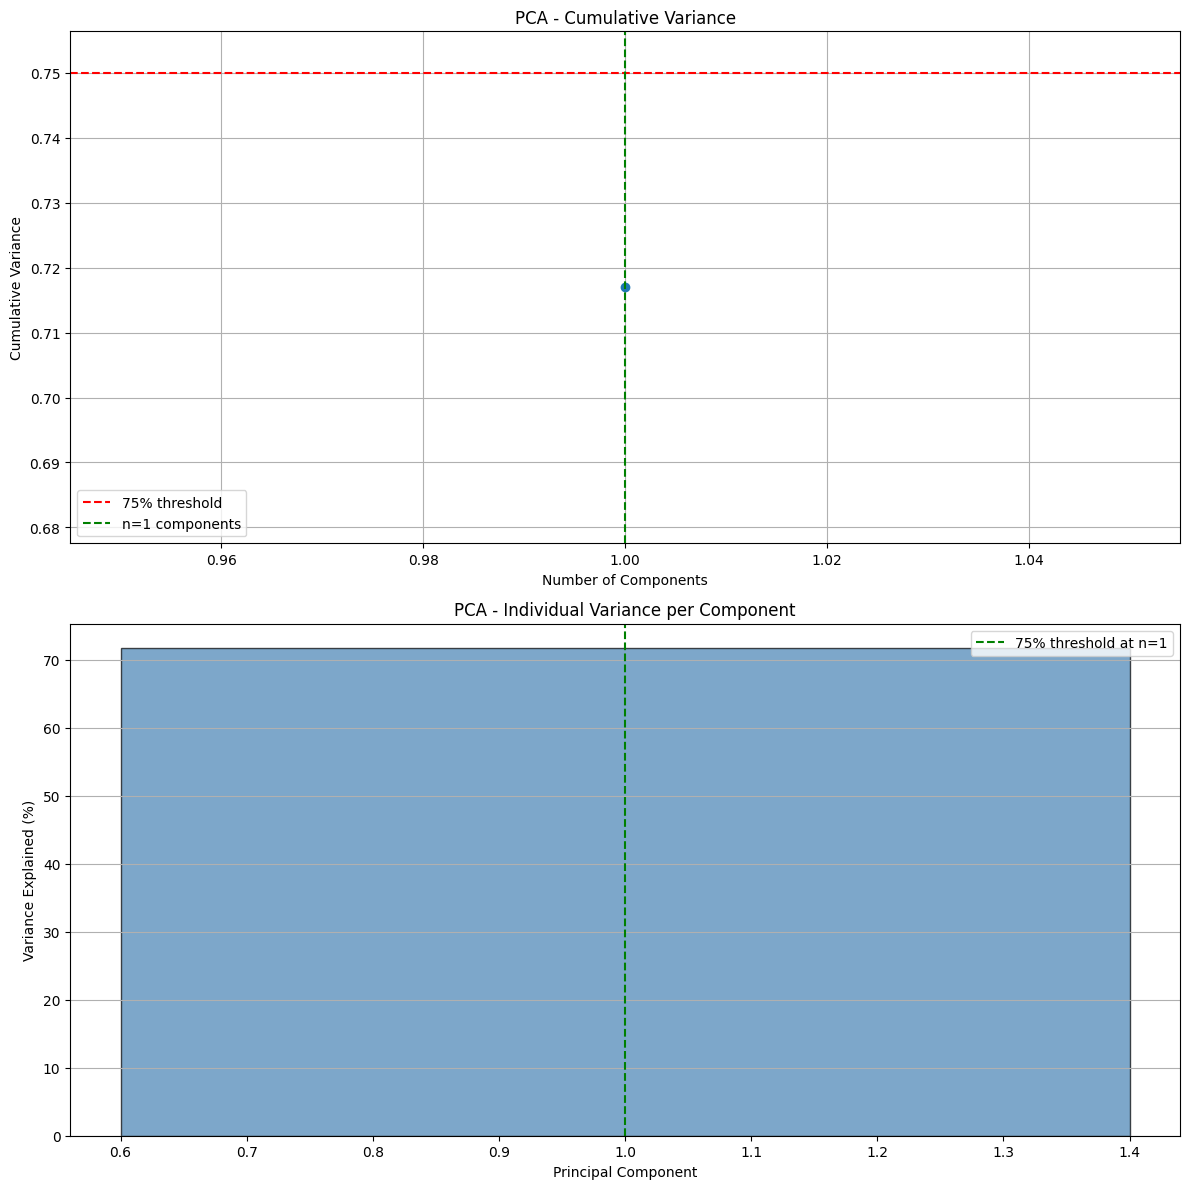

✅ Components needed for 75% variance: 1
✅ Variance explained by 1 components: 0.7170


In [48]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- Plot 1: Cumulative Variance (your existing plot) ---
cumvar = np.cumsum(pca_coor.explained_variance_ratio_)
n_components_75 = np.argmax(cumvar >= 0.75) + 1

ax1.plot(range(1, len(cumvar)+1), cumvar, marker='o', linewidth=2)
ax1.axhline(y=0.75, color='r', linestyle='--', label='75% threshold')
ax1.axvline(x=n_components_75, color='g', linestyle='--', 
            label=f'n={n_components_75} components')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Variance')
ax1.set_title('PCA - Cumulative Variance')
ax1.legend()
ax1.grid(True)

# --- Plot 2: Individual variance per component (bar chart) ---
ax2.bar(range(1, len(pca_coor.explained_variance_ratio_)+1), 
        pca_coor.explained_variance_ratio_ * 100,
        color='steelblue', alpha=0.7, edgecolor='black')
ax2.axvline(x=n_components_75, color='g', linestyle='--',
            label=f'75% threshold at n={n_components_75}')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Variance Explained (%)')
ax2.set_title('PCA - Individual Variance per Component')
ax2.legend()
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Components needed for 75% variance: {n_components_75}")
print(f"✅ Variance explained by {n_components_75} components: {cumvar[n_components_75-1]:.4f}")

In [49]:
# สร้าง DataFrame สำหรับ PC1 ฝั่งสิ่งแวดล้อม
X_train_pca_env_df = pd.DataFrame(X_train_pca, columns=['PC1_env'])
X_test_pca_env_df = pd.DataFrame(X_test_pca, columns=['PC1_env'])

# สร้าง DataFrame สำหรับ PC1 ฝั่งพิกัด (Coordinates) ตาม Hypothesis A
X_train_pca_coor_df = pd.DataFrame(X_train_coor_pca, columns=['PC1_coor'])
X_test_pca_coor_df = pd.DataFrame(X_test_coor_pca, columns=['PC1_coor'])

# รีเซ็ต index ของข้อมูลดิบส่วนอื่นๆ เพื่อป้องกันปัญหาแถวเลื่อนหรือไม่ตรงกันตอนรวมตาราง
X_train_raw_month = X_train_raw_month.reset_index(drop=True)
X_test_raw_month = X_test_raw_month.reset_index(drop=True)

X_train_raw_fe = X_train_raw_fe.reset_index(drop=True)
X_test_fe = X_test_fe.reset_index(drop=True)

# รวมฟีเจอร์ทั้งหมดเข้าด้วยกันในแนวแกน X (axis=1) ประกอบด้วย: PC1_env, PC1_coor, เดือน และฟีเจอร์ที่ทำ FE
X_train_pca = pd.concat([X_train_pca_env_df, X_train_pca_coor_df, X_train_raw_month, X_train_raw_fe], axis=1)
X_test_pca  = pd.concat([X_test_pca_env_df,  X_test_pca_coor_df,  X_test_raw_month,  X_test_fe],       axis=1)

In [51]:
import optuna
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

# Optuna

In [ ]:
# ============================================================
# Helper: CV with proper preprocessing within fold (Updated Workflow)
# ============================================================
def cv_classif(model_factory, X_env_raw, X_coor_raw, X_fe_raw, X_month_raw, y, cv_splits=5):
    """
    Stratified K-Fold CV ที่จำลอง Preprocessing Workflow ล่าสุดภายในแต่ละ Fold 
    เพื่อป้องกันปัญหา Data Leakage อย่างสมบูรณ์
    """
    X_env_raw = X_env_raw.reset_index(drop=True)
    X_coor_raw = X_coor_raw.reset_index(drop=True)
    X_fe_raw = X_fe_raw.reset_index(drop=True)
    X_month_raw = X_month_raw.reset_index(drop=True)
    y = y.reset_index(drop=True)
    
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in skf.split(X_env_raw, y):
        # ----- 1. Split Data -----
        X_env_tr, X_env_val = X_env_raw.iloc[train_idx], X_env_raw.iloc[val_idx]
        X_coor_tr, X_coor_val = X_coor_raw.iloc[train_idx], X_coor_raw.iloc[val_idx]
        X_fe_tr, X_fe_val = X_fe_raw.iloc[train_idx], X_fe_raw.iloc[val_idx]
        X_month_tr, X_month_val = X_month_raw.iloc[train_idx], X_month_raw.iloc[val_idx]
        
        y_tr = y.iloc[train_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)
        
        # ----- 2. Preprocessing สำหรับ ข้อมูลหลัก (Environment) -----
        imputer_env = SimpleImputer(strategy='median')
        X_env_tr_imp = imputer_env.fit_transform(X_env_tr)
        X_env_val_imp = imputer_env.transform(X_env_val)
        
        scaler_env = StandardScaler()
        X_env_tr_ss = scaler_env.fit_transform(X_env_tr_imp)
        X_env_val_ss = scaler_env.transform(X_env_val_imp)
        
        pca_env = PCA(n_components=1)
        X_env_tr_pca = pca_env.fit_transform(X_env_tr_ss)
        X_env_val_pca = pca_env.transform(X_env_val_ss)
        
        # ----- 3. Preprocessing สำหรับ พิกัด (Coordinates) -----
        imputer_coor = SimpleImputer(strategy='median')
        X_coor_tr_imp = imputer_coor.fit_transform(X_coor_tr)
        X_coor_val_imp = imputer_coor.transform(X_coor_val)
        
        scaler_coor = StandardScaler()
        X_coor_tr_ss = scaler_coor.fit_transform(X_coor_tr_imp)
        X_coor_val_ss = scaler_coor.transform(X_coor_val_imp)
        
        pca_coor = PCA(n_components=1)
        X_coor_tr_pca = pca_coor.fit_transform(X_coor_tr_ss)
        X_coor_val_pca = pca_coor.transform(X_coor_val_ss)
        
        # ----- 4. Preprocessing สำหรับ ฟีเจอร์ที่ทำ FE -----
        imputer_fe = SimpleImputer(strategy='median')
        X_fe_tr_imp = imputer_fe.fit_transform(X_fe_tr)
        X_fe_val_imp = imputer_fe.transform(X_fe_val)
        
        # ----- 5. แปลงทุกส่วนกลับเป็น DataFrame และ Concat รวมกัน -----
        X_tr_env_df = pd.DataFrame(X_env_tr_pca, columns=['PC1_env'])
        X_val_env_df = pd.DataFrame(X_env_val_pca, columns=['PC1_env'])
        
        X_tr_coor_df = pd.DataFrame(X_coor_tr_pca, columns=['PC1_coor'])
        X_val_coor_df = pd.DataFrame(X_coor_val_pca, columns=['PC1_coor'])
        
        X_tr_fe_df = pd.DataFrame(X_fe_tr_imp, columns=X_fe_raw.columns)
        X_val_fe_df = pd.DataFrame(X_fe_val_imp, columns=X_fe_raw.columns)
        
        X_month_tr_df = X_month_tr.reset_index(drop=True)
        X_month_val_df = X_month_val.reset_index(drop=True)
        
        X_tr_final = pd.concat([X_tr_env_df, X_tr_coor_df, X_month_tr_df, X_tr_fe_df], axis=1)
        X_val_final = pd.concat([X_val_env_df, X_val_coor_df, X_month_val_df, X_val_fe_df], axis=1)
        
        # ----- 6. Train & Evaluate -----
        model = model_factory() # สร้างโมเดลใหม่ตามชุดพารามิเตอร์ของแต่ละรอบในทุก Fold
        model.fit(X_tr_final, y_tr)
        y_pred = model.predict(X_val_final)
        scores.append(f1_score(y_val, y_pred, average='weighted'))
    
    return np.mean(scores)


# ============================================================
# 1. Random Forest Objective Function
# ============================================================
def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 600),
        'max_depth':         trial.suggest_int('max_depth', 10, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', None]),
        'random_state':      42,
        'n_jobs':            -1,
    }
    
    def make_model():
        return RandomForestClassifier(**params)
    
    # ส่งชุดข้อมูลดิบแยกชิ้นตามดีไซน์ล่าสุดเข้าไปให้ฟังก์ชัน CV จัดการภายใน Fold
    return cv_classif(
        make_model, 
        X_env_raw=X_train_raw, 
        X_coor_raw=X_train_raw_coor, 
        X_fe_raw=X_train_raw_fe, 
        X_month_raw=X_train_raw_month, 
        y=y_train
    )

# ============================================================
# Run Optuna Study
# ============================================================
studies = {}
n_trials = 50

# ---------- Random Forest ----------
print("=" * 60)
print("🌲 Tuning Random Forest with New Spatial Workflow...")
print("=" * 60)
studies['rf'] = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
studies['rf'].optimize(objective_rf, n_trials=n_trials, show_progress_bar=True)

# ============================================================
# Summary
# ============================================================
print("\n" + "=" * 60)
print("📊 Best Results")
print("=" * 60)
for name, study in studies.items():
    print(f"\n{name.upper()}:")
    print(f"  Best F1:     {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}")

[I 2026-05-16 21:23:22,568] A new study created in memory with name: no-name-7175eece-26f3-4e53-b0ba-07b2dc40a272


🌲 Tuning Random Forest with New Spatial Workflow...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-16 21:23:26,760] Trial 0 finished with value: 0.8642382186536102 and parameters: {'n_estimators': 350, 'max_depth': 48, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8642382186536102.
[I 2026-05-16 21:23:33,063] Trial 1 finished with value: 0.871924528861258 and parameters: {'n_estimators': 223, 'max_depth': 45, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 1 with value: 0.871924528861258.
[I 2026-05-16 21:23:48,486] Trial 2 finished with value: 0.8926365997735924 and parameters: {'n_estimators': 533, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 2 with value: 0.8926365997735924.
[I 2026-05-16 21:23:59,492] Trial 3 finished with value: 0.8880214020203118 and parameters: {'n_estimators': 373, 'max_depth': 21, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None}. Best is trial 2 with value: 0.8926365997735924.
[I 2